# Practice 01 — Linear Regression

One problem solved several ways, all reaching the same answer, each step handing more of the work to
PyTorch.

$$\hat{\mathbf{y}} = \mathbf{Xw}, \qquad
J = \tfrac{1}{2}\lVert\hat{\mathbf{y}} - \mathbf{y}\rVert_2^2, \qquad \mathbf{E} = \mathbf{y} -
\hat{\mathbf{y}}, \qquad \frac{\partial J}{\partial \mathbf{w}} = -\mathbf{X}^T\mathbf{E}, \qquad \mathbf{w}
\leftarrow \mathbf{w} - \rho\,\frac{\partial J}{\partial \mathbf{w}}$$

The bias is absorbed into column 0 of $\mathbf{X}$:

$$\mathbf{X} = \begin{bmatrix} 1 & x_1 \\ \vdots & \vdots \\ 1 & x_N \end{bmatrix}\;(N, 2), \qquad
\mathbf{w} = \begin{bmatrix} w_0 \\ w_1 \end{bmatrix}\;(2, 1)$$

> **Why the $1/2$:** it cancels the constant 2 from differentiating, leaving $-\mathbf{X}^T\mathbf{E}$.
> Autograd differentiates the $J$ written in the code, so without it the two differ by a factor of 2.

| Least Squares | Gradient Descent |
|:---|:---|
| $\mathbf{w}^* = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$ | $\mathbf{w} \leftarrow \mathbf{w} + \rho\,\mathbf{X}^T\mathbf{E}$ |
| solved at once | approached step by step |

---
## Step 0. Imports

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

np.random.seed(42)
torch.manual_seed(42)

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.unicode_minus'] = False

---
## Step 1. Generate Data

We draw $N = 100$ samples from

$$y = 0.1 + 0.3\,x + \mathcal{N}(0,\, 0.1)$$

so $w_0 = 0.1$ and $w_1 = 0.3$ are the true values we are trying to recover.

x shape: (100, 1)
y shape: (100, 1)
True values: w0 = 0.1, w1 = 0.3


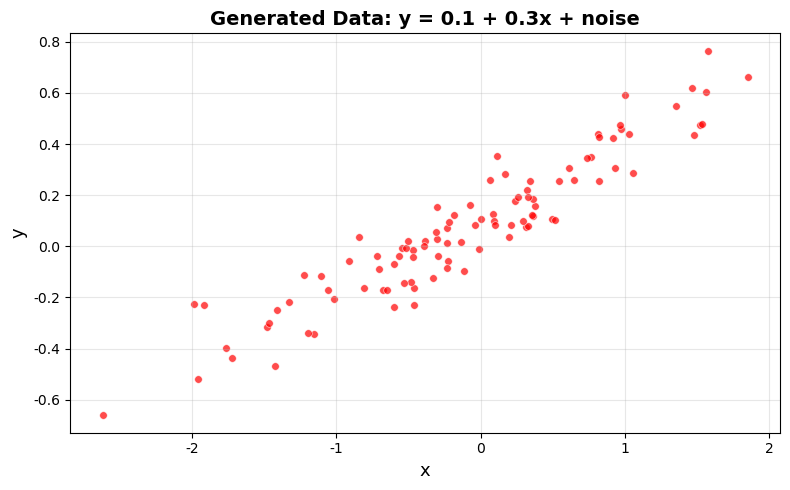

In [2]:
# Ground truth
N  = 100      # number of samples
w0 = 0.1      # intercept
w1 = 0.3      # slope

# Generate data
x = np.random.normal(0.0, 1, N).reshape(-1, 1)
y = w0 + w1 * x
y = y + np.random.normal(0.0, 0.1, N).reshape(-1, 1)

print(f'x shape: {x.shape}')
print(f'y shape: {y.shape}')
print(f'True values: w0 = {w0}, w1 = {w1}')

plt.figure()
plt.scatter(x, y, c='r', s=30, alpha=0.7, edgecolors='white', linewidths=0.5)
plt.xlabel('x', fontsize=13)
plt.ylabel('y', fontsize=13)
plt.title('Generated Data: y = 0.1 + 0.3x + noise', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Step 2. Least Square Method

Prepending a column of ones absorbs the intercept into $\mathbf{w}$, so the model is $\hat{\mathbf{y}} =
\mathbf{Xw}$ and the normal equation gives the answer directly.

$$\mathbf{w}^* = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$

In [3]:
# Augmented matrix X = [1, x]
X = np.hstack([x**0, x])

# Normal equation: w* = (X^T X)^-1 X^T y
# np.linalg.inv() computes the inverse; (X^T X)^-1 cannot be written as-is in code.
w_least_squares = np.linalg.inv(X.T @ X) @ X.T @ y

y_hat_least_squares = X @ w_least_squares

print(f'X shape: {X.shape}')
print(f'w shape: {w_least_squares.shape}')
print()
print('Least Squares result')
print('-' * 46)
print(f'  w0 (intercept) = {w_least_squares[0, 0]:.6f}   (true: {w0})')
print(f'  w1 (slope)     = {w_least_squares[1, 0]:.6f}   (true: {w1})')
print('-' * 46)

X shape: (100, 2)
w shape: (2, 1)

Least Squares result
----------------------------------------------
  w0 (intercept) = 0.100743   (true: 0.1)
  w1 (slope)     = 0.285674   (true: 0.3)
----------------------------------------------


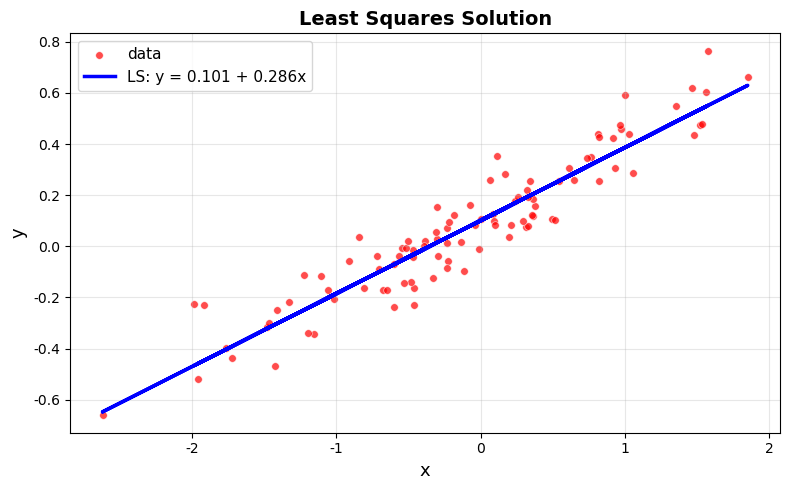

In [4]:
plt.figure()
plt.scatter(x, y, c='r', s=30, alpha=0.7, edgecolors='white', linewidths=0.5, label='data')
plt.plot(x, y_hat_least_squares, 'b-', linewidth=2.5,
         label=f'LS: y = {w_least_squares[0, 0]:.3f} + {w_least_squares[1, 0]:.3f}x')
plt.xlabel('x', fontsize=13)
plt.ylabel('y', fontsize=13)
plt.title('Least Squares Solution', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Step 3. Gradient Descent — NumPy

When $\mathbf{w}^*$ has no closed form, step against the gradient instead — four lines:

$$\hat{\mathbf{y}} = \mathbf{Xw} \;\rightarrow\;
\mathbf{E} = \mathbf{y} - \hat{\mathbf{y}} \;\rightarrow\; \frac{\partial J}{\partial \mathbf{w}} =
-\mathbf{X}^T\mathbf{E} \;\rightarrow\; \mathbf{w} \leftarrow \mathbf{w} - \rho\,\frac{\partial J}{\partial
\mathbf{w}}$$

`w_init`, `rho` and `n_iter` are set here and **reused by every method below**, or the comparison would not
hold.

In [5]:
# Settings shared by every gradient descent method below
w_init = np.random.randn(2, 1)   # initial weights (random)
rho    = 0.00002                 # learning rate (step size)
n_iter = 3000                    # number of iterations

print(f'Initial w = ({w_init[0, 0]:.4f}, {w_init[1, 0]:.4f})')
print(f'Learning rate rho = {rho}')
print(f'Iterations = {n_iter}')
print()

w_numpy = w_init.copy()
loss_history_numpy = []
w_history = []

for i in range(n_iter):
    y_hat = X @ w_numpy               # 1) prediction
    E     = y - y_hat                 # 2) residual
    dJ    = -X.T @ E                  # 3) gradient
    w_numpy = w_numpy - rho * dJ      # 4) update

    loss = float((E ** 2).sum() / 2)  # J = (1/2)||E||^2
    loss_history_numpy.append(loss)
    w_history.append(w_numpy[:, 0])

    if i % 500 == 0 or i == n_iter - 1:
        print(f'iter={i:5d}  w0={w_numpy[0, 0]:+.6f}  w1={w_numpy[1, 0]:+.6f}  J={loss:.6f}')

y_hat_numpy = X @ w_numpy

print()
print('Gradient Descent (NumPy) result')
print('-' * 46)
print(f'  w0 = {w_numpy[0, 0]:.6f}   (true: {w0})')
print(f'  w1 = {w_numpy[1, 0]:.6f}   (true: {w1})')
print('-' * 46)

Initial w = (0.3578, 0.5608)
Learning rate rho = 2e-05
Iterations = 3000

iter=    0  w0=+0.357330  w1=+0.560383  J=6.141816
iter=  500  w0=+0.207069  w1=+0.417044  J=1.579546
iter= 1000  w0=+0.145536  w1=+0.347812  J=0.673686
iter= 1500  w0=+0.119898  w1=+0.314836  J=0.489688
iter= 2000  w0=+0.109042  w1=+0.299282  J=0.451778


iter= 2500  w0=+0.104379  w1=+0.291997  J=0.443899
iter= 2999  w0=+0.102354  w1=+0.288608  J=0.442254

Gradient Descent (NumPy) result
----------------------------------------------
  w0 = 0.102354   (true: 0.1)
  w1 = 0.288608   (true: 0.3)
----------------------------------------------


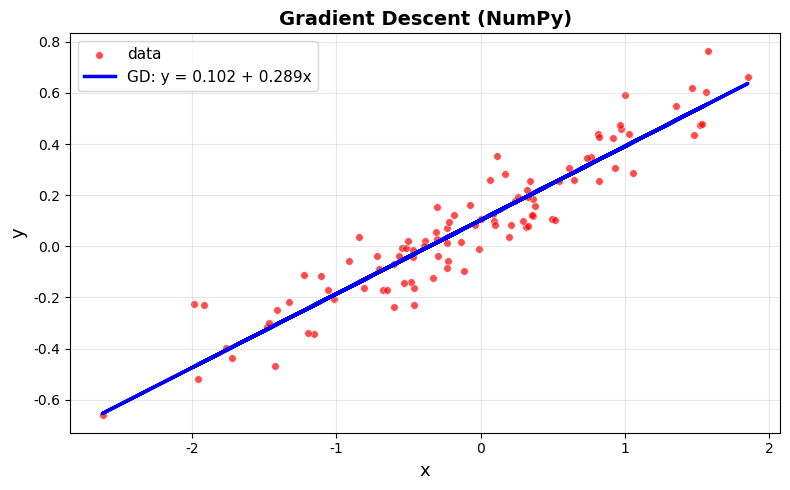

In [6]:
plt.figure()
plt.scatter(x, y, c='r', s=30, alpha=0.7, edgecolors='white', linewidths=0.5, label='data')
plt.plot(x, y_hat_numpy, 'b-', linewidth=2.5,
         label=f'GD: y = {w_numpy[0, 0]:.3f} + {w_numpy[1, 0]:.3f}x')
plt.xlabel('x', fontsize=13)
plt.ylabel('y', fontsize=13)
plt.title('Gradient Descent (NumPy)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

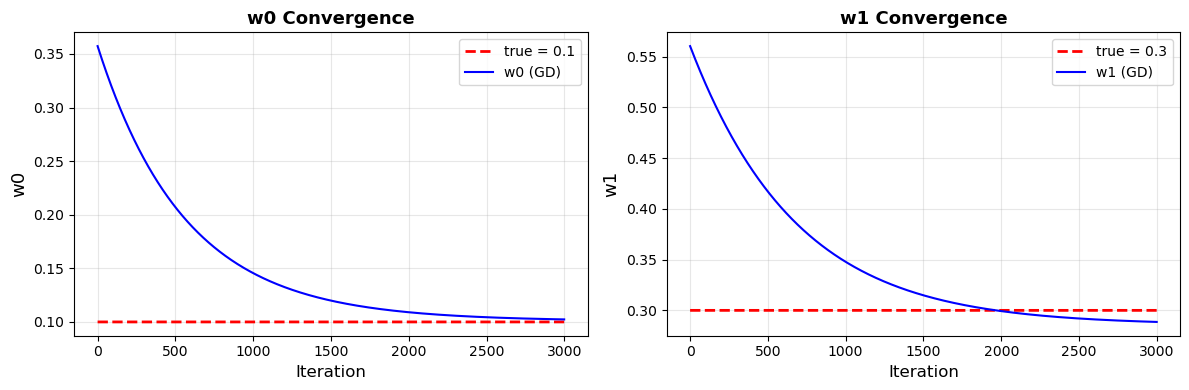

In [7]:
# Weight convergence
w_history = np.array(w_history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(np.arange(n_iter), np.ones(n_iter) * w0, 'r--', linewidth=2, label=f'true = {w0}')
axes[0].plot(w_history[:, 0], 'b-', linewidth=1.5, label='w0 (GD)')
axes[0].set_xlabel('Iteration', fontsize=12)
axes[0].set_ylabel('w0', fontsize=13)
axes[0].set_title('w0 Convergence', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].plot(np.arange(n_iter), np.ones(n_iter) * w1, 'r--', linewidth=2, label=f'true = {w1}')
axes[1].plot(w_history[:, 1], 'b-', linewidth=1.5, label='w1 (GD)')
axes[1].set_xlabel('Iteration', fontsize=12)
axes[1].set_ylabel('w1', fontsize=13)
axes[1].set_title('w1 Convergence', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Step 4. Autograd

Step 3 needed the gradient derived by hand.
PyTorch records the forward computation and differentiates it on `backward()`.

| API | Role |
|:---|:---|
| `torch.tensor(v, requires_grad=True)` | track gradients for this tensor |
| `y.backward()` | compute the derivatives |
| `w_tensor.grad` | read them |

Three examples simple enough to check by hand.

### Example 1: $y = w^2 + 2w + 1$

$$\frac{dy}{dw} = 2w + 2$$

At $w = 2$ we expect $y = 9$ and $\dfrac{dy}{dw} = 6$.

In [8]:
w_value = 2.0   # try other values

w_tensor  = torch.tensor(w_value, requires_grad=True)
y_example = w_tensor**2 + 2*w_tensor + 1

y_example.backward()

print('w:    ', w_tensor.item())
print('y:    ', y_example.item())
print('dy/dw:', w_tensor.grad.item())   # 2w + 2 = 6

w:     2.0
y:     9.0
dy/dw: 6.0


### Example 2: $\hat{y} = xw + 1$

$$\frac{d\hat{y}}{dw} = x$$

At $x = 3$ and $w = 2$ we expect $\hat{y} = 7$ and $\dfrac{d\hat{y}}{dw} = 3$.

In [9]:
x_value = 3.0
w_value = 2.0

w_tensor      = torch.tensor(w_value, requires_grad=True)
y_hat_example = x_value * w_tensor + 1

y_hat_example.backward()

print('w:      ', w_tensor.item())
print('y_hat:  ', y_hat_example.item())
print('dy/dw:  ', w_tensor.grad.item())   # x = 3

w:       2.0
y_hat:   7.0
dy/dw:   3.0


### Example 3: $\hat{y} = xw + 1$, $\; f = \hat{y}^2$ — chain rule

$$\frac{df}{dw} = \frac{d\hat{y}}{dw}\cdot\frac{df}{d\hat{y}} = 2x\hat{y}$$

At $x = 3$, $w = 2$: $\hat{y} = 7$, $f = 49$, $df/dw = 42$.
Two stages, still one `backward()`.

In [10]:
x_value = 3.0
w_value = 2.0

w_tensor      = torch.tensor(w_value, requires_grad=True)
y_hat_example = x_value * w_tensor + 1
f_example     = y_hat_example**2

f_example.backward()

print('w:      ', w_tensor.item())
print('y_hat:  ', y_hat_example.item())
print('f:      ', f_example.item())
print('df/dw:  ', w_tensor.grad.item())   # 2*x*y_hat = 2*3*7 = 42

w:       2.0
y_hat:   7.0
f:       49.0
df/dw:   42.0


---
## Step 5. Hand-Derived Gradient vs. Autograd

Both evaluated at the same $\mathbf{w}$ and printed side by side.
If they agree, the derivation in Step 3 was right.

In [11]:
# Point at which the two gradients are compared (arbitrary w)
w_check = np.array([[1.0], [1.0]])

# Method 1 - from the formula
y_hat = X @ w_check
E     = y - y_hat
dJ_formula = -X.T @ E

# Method 2 - from autograd
X_tensor = torch.tensor(X, dtype=torch.float64)
y_tensor = torch.tensor(y, dtype=torch.float64)
w_check_tensor = torch.tensor(w_check, dtype=torch.float64, requires_grad=True)

loss = ((X_tensor @ w_check_tensor - y_tensor) ** 2).sum() / 2
loss.backward()

print(f'Gradient at w = ({w_check[0, 0]}, {w_check[1, 0]})')
print('-' * 52)
print(f'  formula  : {dJ_formula.flatten()}')
print(f'  autograd : {w_check_tensor.grad.numpy().flatten()}')
print('-' * 52)
print(f'  J = {loss.item():.6f}')

Gradient at w = (1.0, 1.0)
----------------------------------------------------
  formula  : [82.50769791 49.75814305]
  autograd : [82.50769791 49.75814305]
----------------------------------------------------
  J = 55.311398


---
## Step 6. Gradient Descent — autograd, manual update

One line changes from Step 3: `dJ = -X.T @ E` becomes `loss.backward()`.

> `backward()` **accumulates** into `.grad`, so clear it each iteration with `grad.zero_()`.
> The update itself is not differentiated, hence `with torch.no_grad()`.

In [12]:
w_autograd = torch.tensor(w_init, dtype=torch.float64, requires_grad=True)
loss_history_autograd = []

for i in range(n_iter):
    y_hat = X_tensor @ w_autograd
    loss  = ((y_hat - y_tensor) ** 2).sum() / 2

    loss.backward()                          # gradient computed automatically
    with torch.no_grad():
        w_autograd -= rho * w_autograd.grad  # weight update
    w_autograd.grad.zero_()                  # clear the gradient

    loss_history_autograd.append(loss.item())

    if i % 500 == 0 or i == n_iter - 1:
        w_now = w_autograd.detach().numpy()
        print(f'iter={i:5d}  w0={w_now[0, 0]:+.6f}  w1={w_now[1, 0]:+.6f}  J={loss.item():.6f}')

print()
print('Gradient Descent (autograd) result')
print('-' * 46)
print(f'  w0 = {w_autograd[0, 0].item():.6f}   (true: {w0})')
print(f'  w1 = {w_autograd[1, 0].item():.6f}   (true: {w1})')
print('-' * 46)

iter=    0  w0=+0.357330  w1=+0.560383  J=6.141816
iter=  500  w0=+0.207069  w1=+0.417044  J=1.579546
iter= 1000  w0=+0.145536  w1=+0.347812  J=0.673686
iter= 1500  w0=+0.119898  w1=+0.314836  J=0.489688
iter= 2000  w0=+0.109042  w1=+0.299282  J=0.451778
iter= 2500  w0=+0.104379  w1=+0.291997  J=0.443899
iter= 2999  w0=+0.102354  w1=+0.288608  J=0.442254

Gradient Descent (autograd) result
----------------------------------------------
  w0 = 0.102354   (true: 0.1)
  w1 = 0.288608   (true: 0.3)
----------------------------------------------


---
## Step 7. Gradient Descent — `torch.optim.SGD`

The two hand-written lines become `optimizer.step()` and `optimizer.zero_grad()`.
Swapping SGD for Adam later changes one line, not the loop.

The argument is named `lr` by the API; passing `lr=rho` shows it is the same learning rate as before.

In [13]:
w_optimizer = torch.tensor(w_init, dtype=torch.float64, requires_grad=True)
optimizer = torch.optim.SGD([w_optimizer], lr=rho)
loss_history_optimizer = []

for i in range(n_iter):
    y_hat = X_tensor @ w_optimizer
    loss  = ((y_hat - y_tensor) ** 2).sum() / 2

    loss.backward()
    optimizer.step()         # weight update
    optimizer.zero_grad()    # clear the gradient

    loss_history_optimizer.append(loss.item())

    if i % 500 == 0 or i == n_iter - 1:
        w_now = w_optimizer.detach().numpy()
        print(f'iter={i:5d}  w0={w_now[0, 0]:+.6f}  w1={w_now[1, 0]:+.6f}  J={loss.item():.6f}')

print()
print('Gradient Descent (torch.optim.SGD) result')
print('-' * 46)
print(f'  w0 = {w_optimizer[0, 0].item():.6f}   (true: {w0})')
print(f'  w1 = {w_optimizer[1, 0].item():.6f}   (true: {w1})')
print('-' * 46)

iter=    0  w0=+0.357330  w1=+0.560383  J=6.141816
iter=  500  w0=+0.207069  w1=+0.417044  J=1.579546
iter= 1000  w0=+0.145536  w1=+0.347812  J=0.673686
iter= 1500  w0=+0.119898  w1=+0.314836  J=0.489688
iter= 2000  w0=+0.109042  w1=+0.299282  J=0.451778


iter= 2500  w0=+0.104379  w1=+0.291997  J=0.443899
iter= 2999  w0=+0.102354  w1=+0.288608  J=0.442254

Gradient Descent (torch.optim.SGD) result
----------------------------------------------
  w0 = 0.102354   (true: 0.1)
  w1 = 0.288608   (true: 0.3)
----------------------------------------------


---
## Step 8. The Model as a Class — `nn.Module`

The parameters and the forward pass move into a class: layers declared in `__init__`, computation in
`forward`.

| Element | Role |
|:---|:---|
| inherit `nn.Module` | parameter tracking, `.parameters()`, device moves |
| `super().__init__()` | **required** — without it no parameter is tracked |
| `forward(x)` | input to output; call it as `model(x)` |

Two practical points:

- `nn.Linear` has its own bias, so it takes the **raw** `x` of shape $(N, 1)$, not the augmented
  $\mathbf{X}$ — otherwise the bias is added twice.
- Its parameters are randomly initialised; here they are overwritten with `w_init` so this run starts where
  the others did.

In [14]:
class LinearRegressor(torch.nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.linear = torch.nn.Linear(in_features, 1)

    def forward(self, x):
        y_hat = self.linear(x)
        return y_hat


# nn.Linear provides the bias, so the raw x is used instead of the augmented X
x_tensor = torch.tensor(x, dtype=torch.float64)

model = LinearRegressor(in_features=1).double()
with torch.no_grad():
    model.linear.weight.fill_(w_init[1, 0])   # w1
    model.linear.bias.fill_(w_init[0, 0])     # w0

print(model)
print('parameters:', [name for name, _ in model.named_parameters()])
print()

optimizer = torch.optim.SGD(model.parameters(), lr=rho)
loss_history_nn_module = []

for i in range(n_iter):
    y_hat = model(x_tensor)
    loss  = ((y_hat - y_tensor) ** 2).sum() / 2

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    loss_history_nn_module.append(loss.item())

    if i % 500 == 0 or i == n_iter - 1:
        print(f'iter={i:5d}  w0={model.linear.bias.item():+.6f}  w1={model.linear.weight.item():+.6f}  J={loss.item():.6f}')

w_nn_module = np.array([[model.linear.bias.item()], [model.linear.weight.item()]])

print()
print('Gradient Descent (nn.Module) result')
print('-' * 46)
print(f'  w0 = {w_nn_module[0, 0]:.6f}   (true: {w0})')
print(f'  w1 = {w_nn_module[1, 0]:.6f}   (true: {w1})')
print('-' * 46)

LinearRegressor(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)
parameters: ['linear.weight', 'linear.bias']

iter=    0  w0=+0.357330  w1=+0.560383  J=6.141816
iter=  500  w0=+0.207069  w1=+0.417044  J=1.579546
iter= 1000  w0=+0.145536  w1=+0.347812  J=0.673686


iter= 1500  w0=+0.119898  w1=+0.314836  J=0.489688


iter= 2000  w0=+0.109042  w1=+0.299282  J=0.451778
iter= 2500  w0=+0.104379  w1=+0.291997  J=0.443899
iter= 2999  w0=+0.102354  w1=+0.288608  J=0.442254

Gradient Descent (nn.Module) result
----------------------------------------------
  w0 = 0.102354   (true: 0.1)
  w1 = 0.288608   (true: 0.3)
----------------------------------------------


---
## Step 9. The Loss with `nn.MSELoss`

The last hand-written piece.
`reduction` decides how the per-sample errors combine:

| `reduction` | returns |
|:---|:---|
| `'sum'` | $\lVert\mathbf{E}\rVert_2^2$ |
| `'mean'` (default) | $\tfrac{1}{N}\lVert\mathbf{E}\rVert_2^2$ |
| `'none'` | the per-sample vector |

Our $J$ is $\tfrac{1}{2}\lVert\mathbf{E}\rVert_2^2$, so `'sum'` divided by 2 matches.
The default `'mean'` would divide the gradient by $N = 100$, and the same $\rho$ would take steps 100 times
smaller.

Same `LinearRegressor` class as Step 8, restarted from `w_init`.

In [15]:
mse_sum = torch.nn.MSELoss(reduction='sum')   # ||E||^2, summed over samples

model_mseloss = LinearRegressor(in_features=1).double()
with torch.no_grad():
    model_mseloss.linear.weight.fill_(w_init[1, 0])
    model_mseloss.linear.bias.fill_(w_init[0, 0])

optimizer = torch.optim.SGD(model_mseloss.parameters(), lr=rho)
loss_history_nn_mseloss = []

for i in range(n_iter):
    y_hat = model_mseloss(x_tensor)
    loss  = mse_sum(y_hat, y_tensor) / 2      # J = (1/2)||E||^2

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    loss_history_nn_mseloss.append(loss.item())

    if i % 500 == 0 or i == n_iter - 1:
        print(f'iter={i:5d}  w0={model_mseloss.linear.bias.item():+.6f}  w1={model_mseloss.linear.weight.item():+.6f}  J={loss.item():.6f}')

w_nn_mseloss = np.array([[model_mseloss.linear.bias.item()], [model_mseloss.linear.weight.item()]])

print()
print('Gradient Descent (nn.MSELoss) result')
print('-' * 46)
print(f'  w0 = {w_nn_mseloss[0, 0]:.6f}   (true: {w0})')
print(f'  w1 = {w_nn_mseloss[1, 0]:.6f}   (true: {w1})')
print('-' * 46)

iter=    0  w0=+0.357330  w1=+0.560383  J=6.141816


iter=  500  w0=+0.207069  w1=+0.417044  J=1.579546


iter= 1000  w0=+0.145536  w1=+0.347812  J=0.673686
iter= 1500  w0=+0.119898  w1=+0.314836  J=0.489688


iter= 2000  w0=+0.109042  w1=+0.299282  J=0.451778


iter= 2500  w0=+0.104379  w1=+0.291997  J=0.443899


iter= 2999  w0=+0.102354  w1=+0.288608  J=0.442254

Gradient Descent (nn.MSELoss) result
----------------------------------------------
  w0 = 0.102354   (true: 0.1)
  w1 = 0.288608   (true: 0.3)
----------------------------------------------


---
## Step 10. Solving with scikit-learn

`LinearRegression` in scikit-learn computes the least squares solution internally.
There is no need to build the augmented column: pass the original $x$ and the intercept is fitted separately
(`intercept_` is $w_0$, `coef_` is $w_1$).

In [16]:
regressor = LinearRegression()
regressor.fit(x, y)

w_sklearn = np.array([[regressor.intercept_[0]], [regressor.coef_[0, 0]]])

print('scikit-learn result')
print('-' * 46)
print(f'  w0 (intercept_) = {w_sklearn[0, 0]:.6f}   (true: {w0})')
print(f'  w1 (coef_)      = {w_sklearn[1, 0]:.6f}   (true: {w1})')
print('-' * 46)

scikit-learn result
----------------------------------------------
  w0 (intercept_) = 0.100743   (true: 0.1)
  w1 (coef_)      = 0.285674   (true: 0.3)
----------------------------------------------


---
## Step 11. Comparing All Seven Results

The five gradient descent runs shared the data, `w_init`, `rho` and `n_iter`, so they must coincide.
Least squares and scikit-learn solve directly, so they differ by however far 3000 iterations still are from
the optimum.

In [17]:
print('Comparison of methods')
print('=' * 62)
print(f'  True values             : w0 = {w0:9.6f}, w1 = {w1:9.6f}')
print(f'  Least Squares           : w0 = {w_least_squares[0, 0]:9.6f}, w1 = {w_least_squares[1, 0]:9.6f}')
print(f'  scikit-learn            : w0 = {w_sklearn[0, 0]:9.6f}, w1 = {w_sklearn[1, 0]:9.6f}')
print(f'  GD - NumPy              : w0 = {w_numpy[0, 0]:9.6f}, w1 = {w_numpy[1, 0]:9.6f}')
print(f'  GD - torch autograd     : w0 = {w_autograd[0, 0].item():9.6f}, w1 = {w_autograd[1, 0].item():9.6f}')
print(f'  GD - torch optimizer    : w0 = {w_optimizer[0, 0].item():9.6f}, w1 = {w_optimizer[1, 0].item():9.6f}')
print(f'  GD - torch nn.Module    : w0 = {w_nn_module[0, 0]:9.6f}, w1 = {w_nn_module[1, 0]:9.6f}')
print(f'  GD - torch nn.MSELoss   : w0 = {w_nn_mseloss[0, 0]:9.6f}, w1 = {w_nn_mseloss[1, 0]:9.6f}')
print('=' * 62)
print()
print('Final loss J')
print('-' * 62)
print(f'  GD - NumPy              : {loss_history_numpy[-1]:.6f}')
print(f'  GD - torch autograd     : {loss_history_autograd[-1]:.6f}')
print(f'  GD - torch optimizer    : {loss_history_optimizer[-1]:.6f}')
print(f'  GD - torch nn.Module    : {loss_history_nn_module[-1]:.6f}')
print(f'  GD - torch nn.MSELoss   : {loss_history_nn_mseloss[-1]:.6f}')
print('-' * 62)

Comparison of methods
  True values             : w0 =  0.100000, w1 =  0.300000
  Least Squares           : w0 =  0.100743, w1 =  0.285674
  scikit-learn            : w0 =  0.100743, w1 =  0.285674
  GD - NumPy              : w0 =  0.102354, w1 =  0.288608
  GD - torch autograd     : w0 =  0.102354, w1 =  0.288608
  GD - torch optimizer    : w0 =  0.102354, w1 =  0.288608
  GD - torch nn.Module    : w0 =  0.102354, w1 =  0.288608
  GD - torch nn.MSELoss   : w0 =  0.102354, w1 =  0.288608

Final loss J
--------------------------------------------------------------
  GD - NumPy              : 0.442254
  GD - torch autograd     : 0.442254
  GD - torch optimizer    : 0.442254
  GD - torch nn.Module    : 0.442254
  GD - torch nn.MSELoss   : 0.442254
--------------------------------------------------------------


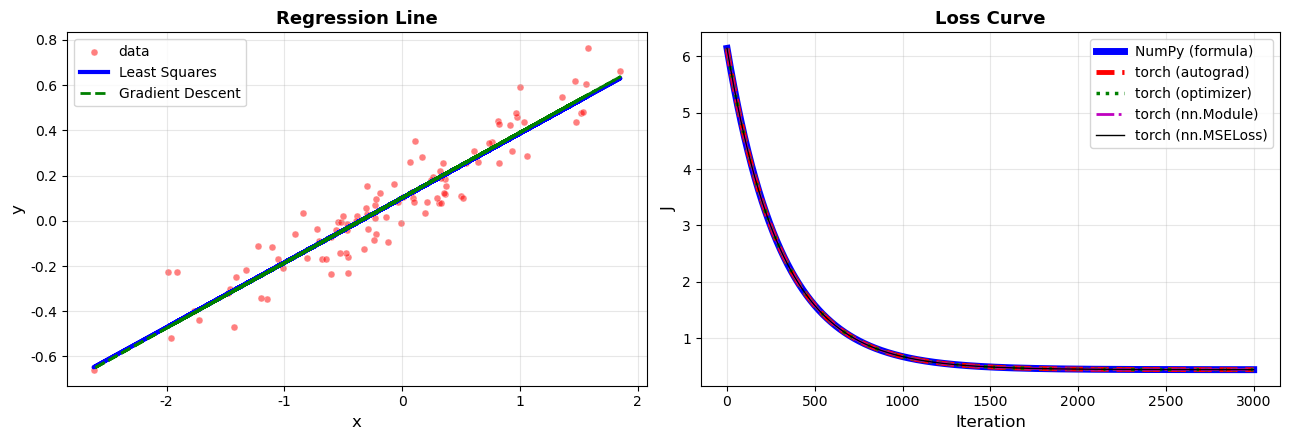

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: regression lines
axes[0].scatter(x, y, c='r', s=25, alpha=0.5, edgecolors='white', linewidths=0.5, label='data')
axes[0].plot(x, y_hat_least_squares, 'b-', linewidth=3, label='Least Squares')
axes[0].plot(x, y_hat_numpy, 'g--', linewidth=2, label='Gradient Descent')
axes[0].set_xlabel('x', fontsize=12)
axes[0].set_ylabel('y', fontsize=12)
axes[0].set_title('Regression Line', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Right: loss curves - check whether the five curves lie exactly on top of each other
axes[1].plot(loss_history_numpy, 'b-', linewidth=5, label='NumPy (formula)')
axes[1].plot(loss_history_autograd, 'r--', linewidth=3.5, label='torch (autograd)')
axes[1].plot(loss_history_optimizer, 'g:', linewidth=2.5, label='torch (optimizer)')
axes[1].plot(loss_history_nn_module, 'm-.', linewidth=2, label='torch (nn.Module)')
axes[1].plot(loss_history_nn_mseloss, 'k-', linewidth=1, label='torch (nn.MSELoss)')
axes[1].set_xlabel('Iteration', fontsize=12)
axes[1].set_ylabel('J', fontsize=12)
axes[1].set_title('Loss Curve', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Summary

| Method | Gradient | Update | Still by hand |
|:---|:---|:---|:---|
| NumPy | `-X.T @ E` | `w - rho * dJ` | loss, model |
| autograd | `loss.backward()` | `w -= rho * w.grad` | loss, model |
| optimizer | `loss.backward()` | `optimizer.step()` | loss, model |
| nn.Module | `loss.backward()` | `optimizer.step()` | loss |
| nn.MSELoss | `loss.backward()` | `optimizer.step()` | — |

Each row hands one more piece to PyTorch without changing the arithmetic, so the five loss curves lie
exactly on top of one another.

---
## Exercises

1. Raise the learning rate to `rho = 0.0001`, then `0.001`.
   What happens?
2. With `n_iter = 100`, does gradient descent reach the least squares solution?
3. Set `w0 = 2.0`, `w1 = -0.5` and solve again.
4. Add a second input: $\hat{y} = w_0 + w_1 x_1 + w_2 x_2$.
   $\mathbf{X}$ becomes $(N, 3)$ and $\mathbf{w}$ becomes $(3, 1)$ — **the four lines of code do not
   change.**

In [19]:
# Write your code here